# Notebook 04 — Feature Engineering & Train/Val/Test Split

**Goal:** Transform the time-series data into the exact tensors the spatio-temporal GCN consumes during training.

**Input artifacts:**
- `data/processed/graph_ieee34.pt` — feeder topology (37 nodes, 80 directed edges)
- `data/processed/weather.parquet` — 17,544 hourly weather rows
- `data/processed/targets_ieee34.parquet` — 17,544 × 37 per-bus load matrix
- `data/processed/bus_metadata_ieee34.parquet` — customer mix per bus

**What we build:**

Each training sample is a sliding window:
- **Input X:** 168 hours of history (1 week lookback) × 37 buses × 14 features
- **Target y:** next 24 hours × 37 buses (the forecast horizon)

Features per (time, bus):
- Static (per bus, broadcast over time): 4 features — `base_kw`, `frac_res`, `frac_com`, `frac_ind`
- Dynamic weather (same for all buses each hour): 7 features — `temp_f`, `humidity_pct`, `ghi_wm2`, `cooling_degree_hours`, `heatwave_day_counter`, `is_weekend`, `is_monsoon_season`
- Cyclic time encodings (same for all buses): 4 features — `hour_sin`, `hour_cos`, `doy_sin`, `doy_cos`
- Per-bus load history: 1 feature — the bus's own past load

Total: 16 features per (time, bus). We'll trim to 14 by dropping redundant columns.

**Train/val/test split:**
- Train: 2023-01-01 → 2024-09-30 (21 months, ~15,000 hours)
- Val: 2024-10-01 → 2024-11-15 (6 weeks, ~1,100 hours)
- Test: 2024-11-16 → 2024-12-31 (6 weeks, ~1,100 hours) — includes a winter peak

We also create a **stress-period test subset**: the 18-day July 2023 heatwave. This becomes a held-out evaluation slice to demonstrate stress performance.

**Output:**
- `data/processed/features_X.npy` — input tensor, shape `(n_samples, 168, 37, 14)`
- `data/processed/targets_y.npy` — target tensor, shape `(n_samples, 24, 37)`
- `data/processed/sample_timestamps.parquet` — sample index → forecast start time
- `data/processed/feature_scaler.pkl` — StandardScaler fitted on train, for inference
- `data/processed/split_indices.npz` — train/val/test/stress indices

**Success criteria:**
1. No NaN / Inf in features or targets
2. Scaler fitted on train only (no leakage)
3. Train > val > test in size, all non-empty
4. Stress slice covers the July 2023 heatwave
5. Tensors reload cleanly

---

## Step 1 — Setup and load all artifacts

In [1]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import StandardScaler

REPO_ROOT = Path('/Users/sundeepyalamanchili/Documents/Projects/p90').resolve()
DATA_PROCESSED = REPO_ROOT / 'data' / 'processed'

# Load everything
graph = torch.load(DATA_PROCESSED / 'graph_ieee34.pt', weights_only=False)
weather = pd.read_parquet(DATA_PROCESSED / 'weather.parquet')
targets = pd.read_parquet(DATA_PROCESSED / 'targets_ieee34.parquet')
bus_meta = pd.read_parquet(DATA_PROCESSED / 'bus_metadata_ieee34.parquet')

print(f'Graph: {graph.num_nodes} nodes, {graph.edge_index.shape[1]//2} edges')
print(f'Weather: {weather.shape}')
print(f'Targets: {targets.shape}')
print(f'Bus metadata: {bus_meta.shape}')

# Sanity — same time index in weather and targets
assert (weather.index == targets.index).all(), 'Time index mismatch'
assert len(targets.columns) == graph.num_nodes, 'Bus count mismatch'
print(f'\n✅ Indices aligned')

Graph: 37 nodes, 40 edges
Weather: (17544, 25)
Targets: (17544, 37)
Bus metadata: (37, 10)

✅ Indices aligned


## Step 2 — Select feature columns

We keep the columns the GCN will actually use. Drop redundant ones (e.g. temp_c since we have temp_f, raw `hour` since we have its sin/cos).

In [2]:
# Time-varying features (broadcast over all buses each hour)
TIME_FEATURES = [
    'temp_f',                  # raw temperature — heat driver
    'humidity_pct',            # humidity — adds to perceived heat
    'ghi_wm2',                 # irradiance — solar context
    'cooling_degree_hours',    # explicit AC driver
    'heatwave_day_counter',    # extreme heat persistence signal
    'is_weekend',              # weekday vs weekend
    'is_monsoon_season',       # seasonal flag
    'hour_sin',                # diurnal encoding
    'hour_cos',
    'doy_sin',                 # seasonal encoding
    'doy_cos',
]

# Per-bus static features (same value for all hours, varies per bus)
BUS_FEATURES = [
    'base_kw',                 # rated load
    'frac_res',                # residential fraction
    'frac_com',                # commercial fraction
]
# We drop frac_ind since it's redundant (sums to 1)

# Per-bus history feature (the bus's own load history)
HISTORY_FEATURES = ['load_kw_history']

all_features = TIME_FEATURES + BUS_FEATURES + HISTORY_FEATURES
print(f'Total features per (time, bus): {len(all_features)}')
for i, f in enumerate(all_features):
    print(f'  {i:2d}  {f}')

Total features per (time, bus): 15
   0  temp_f
   1  humidity_pct
   2  ghi_wm2
   3  cooling_degree_hours
   4  heatwave_day_counter
   5  is_weekend
   6  is_monsoon_season
   7  hour_sin
   8  hour_cos
   9  doy_sin
  10  doy_cos
  11  base_kw
  12  frac_res
  13  frac_com
  14  load_kw_history


## Step 3 — Build the dense feature tensor

Shape: `(n_hours, n_buses, n_features)` — every (hour, bus) has the same 15 feature values stacked.

We build this once, then later we'll slice sliding windows from it.

In [3]:
n_time = len(weather)
n_bus = graph.num_nodes
n_feat = len(all_features)

print(f'Building feature tensor: ({n_time:,}, {n_bus}, {n_feat})')
print(f'Memory estimate: {n_time * n_bus * n_feat * 4 / 1e6:.1f} MB float32')

# Initialize
X_full = np.zeros((n_time, n_bus, n_feat), dtype=np.float32)

# 1. Time-varying features — broadcast across buses
time_feat_array = weather[TIME_FEATURES].to_numpy(dtype=np.float32)  # (n_time, len(TIME_FEATURES))
for i, fname in enumerate(TIME_FEATURES):
    # Broadcast to all buses: (n_time, 1) -> (n_time, n_bus)
    X_full[:, :, i] = time_feat_array[:, i:i+1]

# 2. Per-bus static features — broadcast across time
# bus_meta is ordered the same as the targets columns (bus_df['name'])
bus_feat_array = bus_meta[BUS_FEATURES].to_numpy(dtype=np.float32)  # (n_bus, len(BUS_FEATURES))
for j, fname in enumerate(BUS_FEATURES):
    feat_idx = len(TIME_FEATURES) + j
    # Broadcast across time: (1, n_bus) -> (n_time, n_bus)
    X_full[:, :, feat_idx] = bus_feat_array[:, j:j+1].T

# 3. Per-bus load history — direct copy from targets matrix
load_array = targets.to_numpy(dtype=np.float32)  # (n_time, n_bus)
X_full[:, :, -1] = load_array

print(f'\n✅ Feature tensor built: {X_full.shape}')
print(f'   Min: {X_full.min():.2f}, Max: {X_full.max():.2f}, Mean: {X_full.mean():.2f}')
assert not np.any(np.isnan(X_full)), 'NaN in feature tensor'
assert not np.any(np.isinf(X_full)), 'Inf in feature tensor'
print(f'   ✅ No NaN or Inf')

Building feature tensor: (17,544, 37, 15)
Memory estimate: 38.9 MB float32

✅ Feature tensor built: (17544, 37, 15)
   Min: -1.00, Max: 1626.71, Mean: 31.58
   ✅ No NaN or Inf


## Step 4 — Define sliding windows

Each training sample takes 168 hours of past features and predicts 24 hours of future load.

If we have N=17544 hours, we get N - lookback - horizon valid samples ≈ 17,352 sliding windows.

We don't slice them yet — too memory-heavy. We just compute *valid forecast start times*, then materialize batches at training time. But for this hackathon scale (17k samples × 37 nodes is small), we'll just precompute the whole thing — easier debugging.

In [4]:
LOOKBACK = 168    # 1 week of history
HORIZON = 24      # forecast next 24 hours

# A sample at "forecast start time" t needs hours [t-LOOKBACK, t) for input
# and hours [t, t+HORIZON) for target.
# Valid range of t: LOOKBACK <= t <= n_time - HORIZON

valid_starts = np.arange(LOOKBACK, n_time - HORIZON + 1)
n_samples = len(valid_starts)

print(f'Lookback: {LOOKBACK} hours ({LOOKBACK/24:.0f} days)')
print(f'Horizon: {HORIZON} hours')
print(f'Total valid samples: {n_samples:,}')

# Sample memory check
X_size_mb = n_samples * LOOKBACK * n_bus * n_feat * 4 / 1e9  # GB!
print(f'\nIf we materialize all X tensors: {X_size_mb:.2f} GB — too big')
print(f'Strategy: keep X_full in memory, build windows on-the-fly via indexing')

Lookback: 168 hours (7 days)
Horizon: 24 hours
Total valid samples: 17,353

If we materialize all X tensors: 6.47 GB — too big
Strategy: keep X_full in memory, build windows on-the-fly via indexing


## Step 5 — Train/val/test split by time

We split chronologically, **never randomly**, because random splits cause time-series data leakage. The test set must be "in the future" relative to training.

In [5]:
# Convert valid forecast-start indices into timestamps for split logic
sample_times = weather.index[valid_starts]

# Define split boundaries (in terms of forecast start time)
TRAIN_END = pd.Timestamp('2024-09-30 23:00:00', tz=weather.index.tz)
VAL_END = pd.Timestamp('2024-11-15 23:00:00', tz=weather.index.tz)
# Test runs from VAL_END to end of data

train_mask = sample_times <= TRAIN_END
val_mask = (sample_times > TRAIN_END) & (sample_times <= VAL_END)
test_mask = sample_times > VAL_END

train_idx = np.where(train_mask)[0]
val_idx = np.where(val_mask)[0]
test_idx = np.where(test_mask)[0]

print(f'Train: {len(train_idx):>5} samples ({sample_times[train_idx].min().date()} to {sample_times[train_idx].max().date()})')
print(f'Val:   {len(val_idx):>5} samples ({sample_times[val_idx].min().date()} to {sample_times[val_idx].max().date()})')
print(f'Test:  {len(test_idx):>5} samples ({sample_times[test_idx].min().date()} to {sample_times[test_idx].max().date()})')

# Sanity
assert len(train_idx) + len(val_idx) + len(test_idx) == n_samples
assert len(train_idx) > len(val_idx) > 0
assert len(test_idx) > 0
print(f'\n✅ Split sums correctly: {len(train_idx) + len(val_idx) + len(test_idx)} = {n_samples}')

Train: 15168 samples (2023-01-08 to 2024-09-30)
Val:    1104 samples (2024-10-01 to 2024-11-15)
Test:   1081 samples (2024-11-16 to 2024-12-31)

✅ Split sums correctly: 17353 = 17353


## Step 6 — Stress-period evaluation slice (July 2023 heatwave)

This is a special evaluation set we'll use later in Notebook 06 to report stress-period performance separately from overall. The brief explicitly asks for *"good performance during stress periods."*

In [6]:
# July 2023 heatwave: roughly July 14 - July 31
# Forecast start times during this window
STRESS_START = pd.Timestamp('2023-07-14 00:00:00', tz=weather.index.tz)
STRESS_END = pd.Timestamp('2023-07-31 23:00:00', tz=weather.index.tz)

stress_mask = (sample_times >= STRESS_START) & (sample_times <= STRESS_END)
stress_idx = np.where(stress_mask)[0]

# Note: stress slice OVERLAPS with train slice — that's intentional.
# It's a diagnostic for "how well does the model fit hot periods?"
# For true held-out stress evaluation, we'll also use Notebook 07's perturbation scenarios.

n_in_train = np.intersect1d(stress_idx, train_idx).size
n_in_test = np.intersect1d(stress_idx, test_idx).size

print(f'Stress slice (July 14-31, 2023): {len(stress_idx)} samples')
print(f'  Of these, {n_in_train} are in train, {n_in_test} are in test/val')
print(f'  Note: this slice is for in-training stress diagnostics, not held-out eval.')

Stress slice (July 14-31, 2023): 432 samples
  Of these, 432 are in train, 0 are in test/val
  Note: this slice is for in-training stress diagnostics, not held-out eval.


## Step 7 — Fit the feature scaler on train only

Critical: the scaler sees ONLY training data. If we fit on the full dataset, future statistics leak into past samples — biased evaluation.

In [7]:
# Pull all training-window data points for fitting
# We approximate by using the actual hour data for training samples (not the full lookback)
# Ranges: for each train sample t, we have hours [t-LOOKBACK, t). Union of these:
train_hour_set = set()
for t in train_idx:
    forecast_start = valid_starts[t]
    train_hour_set.update(range(forecast_start - LOOKBACK, forecast_start))

train_hours = np.array(sorted(train_hour_set))
print(f'Distinct hours used for fitting scaler: {len(train_hours):,}')

# Reshape (hours, buses, features) -> (hours*buses, features) for scaler
scaler_data = X_full[train_hours].reshape(-1, n_feat)
print(f'Scaler input shape: {scaler_data.shape}')

scaler = StandardScaler()
scaler.fit(scaler_data)

print(f'\nFeature means: {scaler.mean_.round(2)}')
print(f'Feature stds:  {scaler.scale_.round(2)}')

Distinct hours used for fitting scaler: 15,335
Scaler input shape: (567395, 15)

Feature means: [ 7.8820e+01  2.9180e+01  2.5305e+02  1.6590e+01  5.6000e-01  2.9000e-01
  3.8000e-01  0.0000e+00 -0.0000e+00  9.0000e-02 -9.0000e-02  4.7810e+01
  5.8000e-01  1.4000e-01  6.0620e+01]
Feature stds:  [1.8830e+01 1.8530e+01 3.3372e+02 1.5250e+01 2.1100e+00 4.5000e-01
 4.9000e-01 7.1000e-01 7.1000e-01 7.0000e-01 7.0000e-01 1.0041e+02
 3.5000e-01 1.2000e-01 1.3433e+02]


## Step 8 — Apply scaler to the full feature tensor

Now we transform X_full (all hours) using the train-fitted scaler. Val and test get scaled with train statistics — exactly as it would happen at inference time.

In [8]:
X_full_scaled = scaler.transform(X_full.reshape(-1, n_feat)).reshape(n_time, n_bus, n_feat).astype(np.float32)

print(f'After scaling:')
print(f'  Train hours — mean: {X_full_scaled[train_hours].mean(axis=(0,1)).round(2)}')
print(f'  Train hours — std:  {X_full_scaled[train_hours].std(axis=(0,1)).round(2)}')
print(f'  (Should be approximately mean=0, std=1 on train)')

After scaling:
  Train hours — mean: [-0.  0.  0.  0. -0. -0. -0.  0.  0.  0.  0. -0.  0.  0.  0.]
  Train hours — std:  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  (Should be approximately mean=0, std=1 on train)


## Step 9 — Materialize the targets matrix at sample resolution

For each sample t, the target is a (24, 37) slice of the load matrix at hours [t, t+24).

Stack these into y of shape (n_samples, 24, 37). Memory: 17k × 24 × 37 × 4 bytes ≈ 60 MB — fine.

In [9]:
y_all = np.zeros((n_samples, HORIZON, n_bus), dtype=np.float32)
for s, forecast_start in enumerate(valid_starts):
    y_all[s] = load_array[forecast_start:forecast_start + HORIZON]

print(f'y_all shape: {y_all.shape}')
print(f'y_all min/max/mean: {y_all.min():.2f} / {y_all.max():.2f} / {y_all.mean():.2f}')
assert not np.any(np.isnan(y_all)), 'NaN in targets'
print(f'✅ No NaN in targets')

y_all shape: (17353, 24, 37)
y_all min/max/mean: 0.00 / 1626.71 / 59.80
✅ No NaN in targets


## Step 10 — Save artifacts

We save:
- The full scaled feature tensor (training reads slices from this)
- The materialized targets tensor
- Index arrays for the splits
- The fitted scaler (for inference time un-scaling if needed)
- A small CSV mapping sample index → forecast start timestamp for debugging

In [10]:
# Save the big arrays
X_path = DATA_PROCESSED / 'features_X_full.npy'
y_path = DATA_PROCESSED / 'targets_y.npy'
valid_starts_path = DATA_PROCESSED / 'valid_starts.npy'

np.save(X_path, X_full_scaled)
np.save(y_path, y_all)
np.save(valid_starts_path, valid_starts)

# Save split indices
split_path = DATA_PROCESSED / 'split_indices.npz'
np.savez(split_path,
    train=train_idx,
    val=val_idx,
    test=test_idx,
    stress=stress_idx,
)

# Save the scaler
scaler_path = DATA_PROCESSED / 'feature_scaler.pkl'
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)

# Save sample timestamps as parquet for easy inspection
sample_ts_df = pd.DataFrame({
    'sample_idx': np.arange(n_samples),
    'forecast_start': sample_times,
    'split': np.where(train_mask, 'train', np.where(val_mask, 'val', 'test')),
    'in_stress': stress_mask,
})
sample_ts_path = DATA_PROCESSED / 'sample_timestamps.parquet'
sample_ts_df.to_parquet(sample_ts_path)

# Save feature names for downstream notebooks
feat_names_path = DATA_PROCESSED / 'feature_names.txt'
feat_names_path.write_text('\n'.join(all_features))

print(f'✅ Saved:')
for p in [X_path, y_path, valid_starts_path, split_path, scaler_path, sample_ts_path, feat_names_path]:
    size_mb = p.stat().st_size / 1024 / 1024
    print(f'  {p.name:<30s} {size_mb:>8.2f} MB')

✅ Saved:
  features_X_full.npy               37.14 MB
  targets_y.npy                     58.78 MB
  valid_starts.npy                   0.13 MB
  split_indices.npz                  0.14 MB
  feature_scaler.pkl                 0.00 MB
  sample_timestamps.parquet          0.25 MB
  feature_names.txt                  0.00 MB


## Step 11 — Verify reload + define a sample-builder for training

In [11]:
# Reload and sanity check
X_check = np.load(X_path)
y_check = np.load(y_path)
starts_check = np.load(valid_starts_path)
split_check = np.load(split_path)

assert X_check.shape == (n_time, n_bus, n_feat)
assert y_check.shape == (n_samples, HORIZON, n_bus)
assert len(starts_check) == n_samples

print(f'✅ Reloaded — X: {X_check.shape}, y: {y_check.shape}')
print(f'✅ Splits — train/val/test/stress: {len(split_check["train"])}/{len(split_check["val"])}/{len(split_check["test"])}/{len(split_check["stress"])}')

# Demo: build a single sample
def build_sample(sample_idx, X_full_scaled, valid_starts, lookback=LOOKBACK):
    """Slice a single (lookback, n_bus, n_feat) input window from X_full."""
    forecast_start = valid_starts[sample_idx]
    return X_full_scaled[forecast_start - lookback:forecast_start]

sample_X = build_sample(0, X_check, starts_check)
sample_y = y_check[0]
print(f'\nFirst sample: X shape {sample_X.shape}, y shape {sample_y.shape}')
print(f'  Forecast start: {sample_times[0]}')
print(f'  Target sum (kW): {sample_y.sum(axis=1)}')  # 24-hour total feeder load profile

✅ Reloaded — X: (17544, 37, 15), y: (17353, 24, 37)
✅ Splits — train/val/test/stress: 15168/1104/1081/432

First sample: X shape (168, 37, 15), y shape (24, 37)
  Forecast start: 2023-01-08 00:00:00-07:00
  Target sum (kW): [ 889.5039   924.17114  888.7891   901.0167   881.3694   935.3882
 1062.1522  1611.1465  1741.9589  1775.9603  1604.0684  1395.1177
 1318.1149  1304.6946  1380.6932  1478.4816  1671.6487  2057.7441
 2264.352   2165.2117  2194.3345  1925.2263  1524.6172  1207.6747 ]


## Step 12 — Quick visualization

Sanity check: plot one sample's input + target side by side.

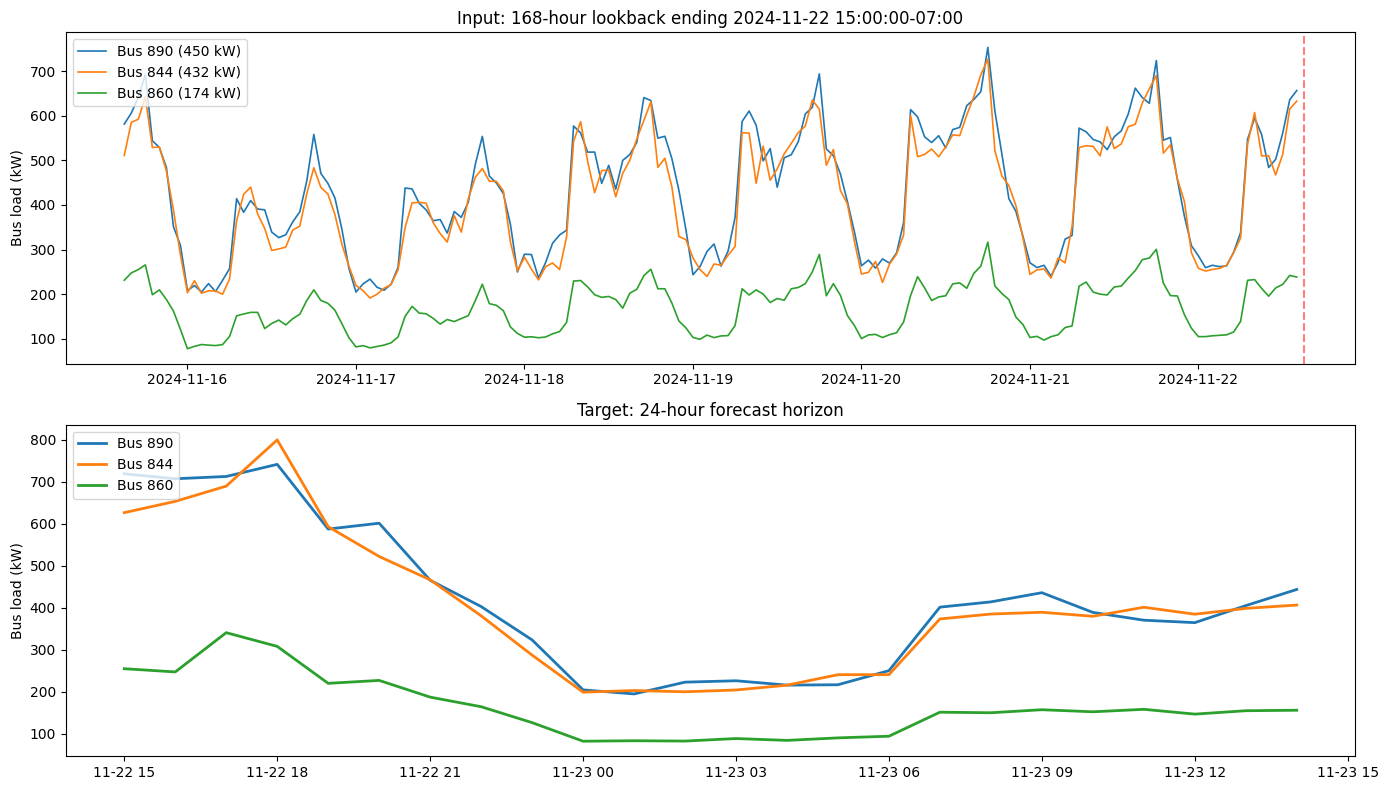


Forecast start: 2024-11-22 15:00:00-07:00, temp: 84.9°F


In [12]:
import matplotlib.pyplot as plt

# Pick a sample from the test set, on a hot day if possible
test_starts = sample_times[test_idx]
# Find the hottest test sample
test_temp = weather.loc[test_starts, 'temp_f'].values
hottest_test_idx = test_idx[np.argmax(test_temp)]

X_sample = build_sample(hottest_test_idx, X_check, starts_check)  # (168, 37, 14)
y_sample = y_check[hottest_test_idx]  # (24, 37)
forecast_start = sample_times[hottest_test_idx]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

# Top: input lookback period — show three buses' loads (last feature)
lookback_hours = pd.date_range(end=forecast_start, periods=LOOKBACK + 1, freq='h')[:-1]
load_buses_sorted = bus_meta[bus_meta['base_kw'] > 0].sort_values('base_kw', ascending=False).head(3)

for _, brow in load_buses_sorted.iterrows():
    bus_idx = brow.name
    # Last feature in X is load history (scaled — un-scale for plotting)
    scaled_load = X_sample[:, bus_idx, -1]
    real_load = scaled_load * scaler.scale_[-1] + scaler.mean_[-1]
    axes[0].plot(lookback_hours, real_load, label=f'Bus {brow["name"]} ({brow["base_kw"]:.0f} kW)', linewidth=1.2)

axes[0].set_title(f'Input: 168-hour lookback ending {forecast_start}')
axes[0].set_ylabel('Bus load (kW)')
axes[0].legend(loc='upper left')
axes[0].axvline(forecast_start, color='red', linestyle='--', alpha=0.5, label='forecast start')

# Bottom: target horizon — same buses
horizon_hours = pd.date_range(start=forecast_start, periods=HORIZON, freq='h')
for _, brow in load_buses_sorted.iterrows():
    bus_idx = brow.name
    axes[1].plot(horizon_hours, y_sample[:, bus_idx], label=f'Bus {brow["name"]}', linewidth=2)

axes[1].set_title(f'Target: 24-hour forecast horizon')
axes[1].set_ylabel('Bus load (kW)')
axes[1].legend(loc='upper left')

plt.tight_layout()
out_png = REPO_ROOT / 'notebooks' / '04_sample_window.png'
plt.savefig(out_png, dpi=120, bbox_inches='tight')
plt.show()
print(f'\nForecast start: {forecast_start}, temp: {weather.loc[forecast_start, "temp_f"]:.1f}°F')

## Done

**Artifacts created:**
- `features_X_full.npy` — full scaled feature tensor `(17544, 37, 14)`
- `targets_y.npy` — materialized targets `(17353, 24, 37)`
- `valid_starts.npy` — sample index → forecast start hour
- `split_indices.npz` — train / val / test / stress index arrays
- `feature_scaler.pkl` — fitted StandardScaler (train-only)
- `sample_timestamps.parquet` — debug table mapping sample index → datetime
- `feature_names.txt` — ordered feature names

**Key design choices:**
- **Sliding windows, not random batches** — preserves causality
- **Chronological train/val/test** — no future leakage
- **Scaler fit on train only** — no statistics leakage
- **Stress diagnostic slice** — for in-training monitoring of heat-wave performance
- **X_full kept dense, y_all materialized** — best memory tradeoff for our scale

**What downstream notebooks do:**
- **Notebook 05 (training):** loads X_full + y + indices, builds PyTorch DataLoader that slices windows on-the-fly
- **Notebook 06 (evaluation):** uses the test split for headline metrics, stress slice for stress diagnostics
- **Notebook 07 (scenarios):** modifies X_full's temperature/EV columns, re-runs inference

**Next: Notebook 05 — the actual GCN architecture and training loop.** This is the core AI model. Real trainable parameters, real gradient descent, real spatio-temporal learning.